In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data = fetch_openml(name='boston', version=1, as_frame=True)

X = data.data
y = data.target.astype(float)

print(X.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [3]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (506, 13)
Target Shape: (506,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [7]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 609.2820 - mae: 22.7243 - val_loss: 524.0898 - val_mae: 21.2804
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 558.9259 - mae: 21.5360 - val_loss: 464.5309 - val_mae: 19.7843
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 481.2262 - mae: 19.5090 - val_loss: 364.6656 - val_mae: 17.0753
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 356.1477 - mae: 16.1833 - val_loss: 219.5666 - val_mae: 12.7300
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 199.2789 - mae: 11.7341 - val_loss: 84.3308 - val_mae: 7.3265
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 85.9212 - mae: 7.4563 - val_loss: 39.6993 - val_mae: 4.5672
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 60.0806 - mae: 6.0026 - val_loss: 31.1234 - val_mae: 3.9471
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 37.4957 - mae: 4.6200 - val_loss: 28.3465 - val_mae: 3.7850
Epoch 9/150
11/11 ━━━━

In [9]:
loss, mae = model.evaluate(X_test, y_test)

print("Mean Absolute Error:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 11.5790 - mae: 2.1727
Mean Absolute Error: 2.1726770401000977


In [10]:
pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


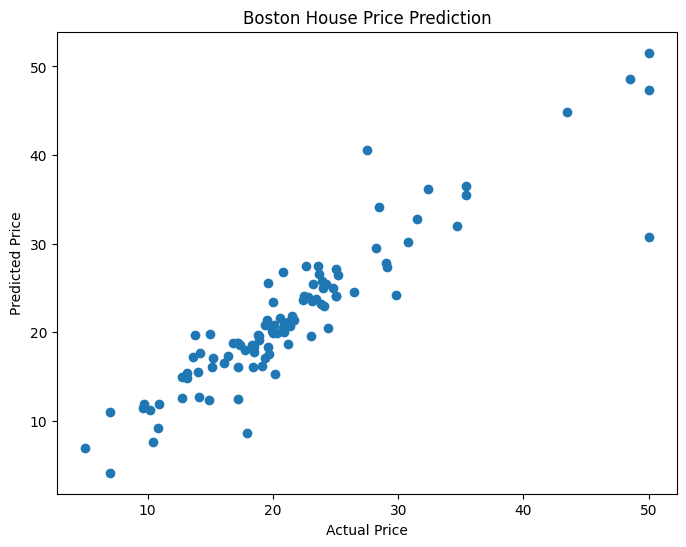

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Boston House Price Prediction")
plt.show()
